<a href="https://colab.research.google.com/github/Flaviomental1/Modelizado-de-Sistemas-con-AI/blob/main/Copia_de_Pracitica_Unidad_2_Algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [ ]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 22.2 MB/s eta 0:00:00


In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}


MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)



## Si usan PyGAD:

In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

## Si usan DEAP:

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

Iniciando la optimización con PyGAD...
¡Optimización finalizada con éxito!

¡CRONOGRAMA OPTIMIZADO POR PYGAD!
Prioridad óptima (IDs): [3, 5, 0, 2, 4, 1, 8, 7, 6, 9]
Orden recomendado: Instalaciones, Pisos, Cimientos, Techo, Revoque, Muros, Electricidad, Aberturas, Pintura, Final de obra
Duración total óptima de la obra: 16 días
Valor de Fitness alcanzado: 0.062500

Uso diario de operarios (Restricción técnica: Máximo 10):
  Día  0: 10 operarios activos -> [OK]


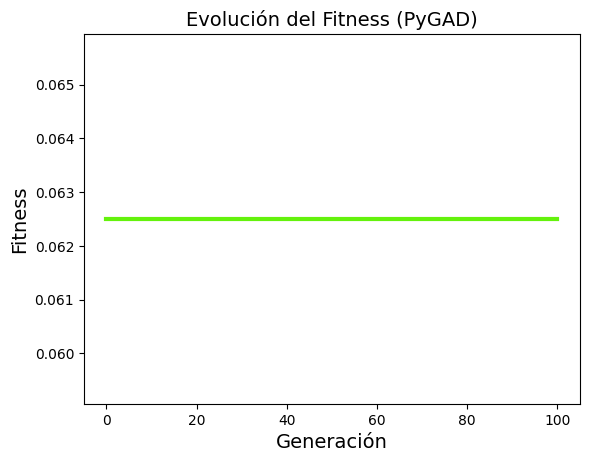

  Día  1: 10 operarios activos -> [OK]


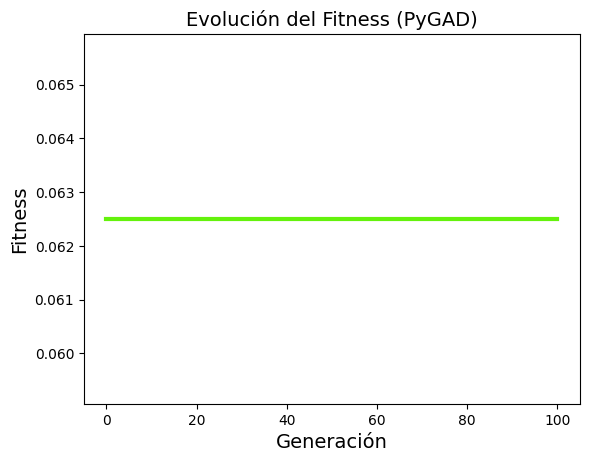

  Día  2: 10 operarios activos -> [OK]


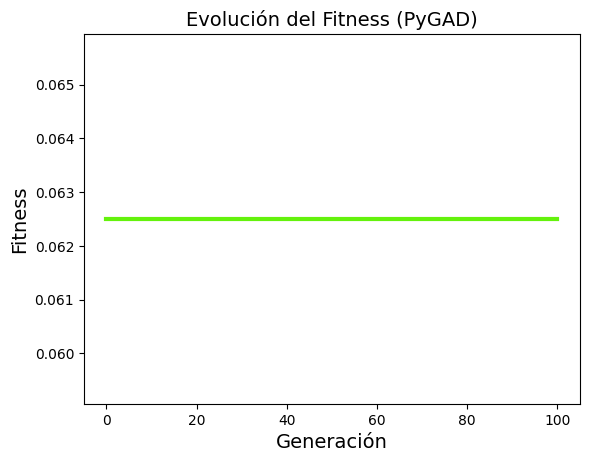

  Día  3: 10 operarios activos -> [OK]


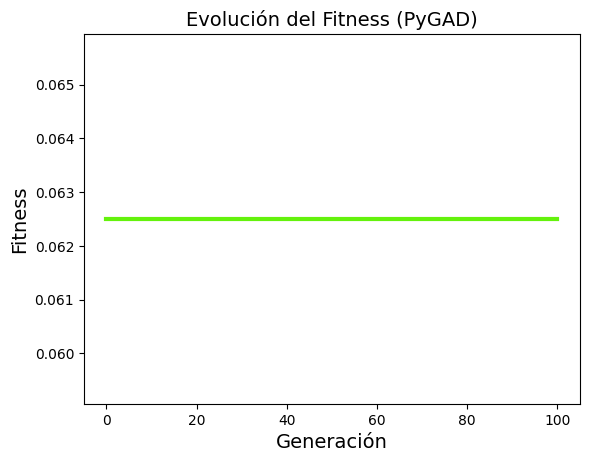

  Día  4:  9 operarios activos -> [OK]


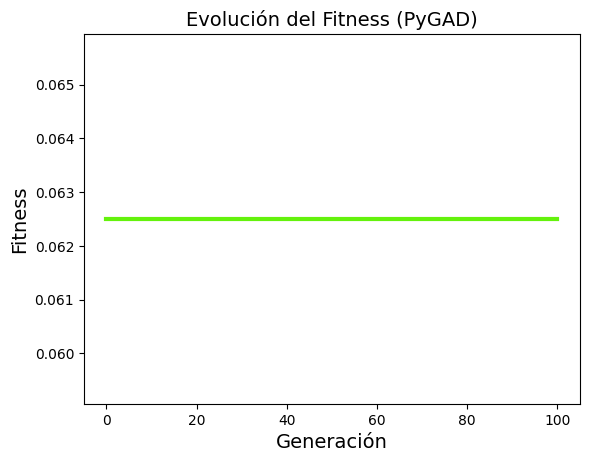

  Día  5: 10 operarios activos -> [OK]


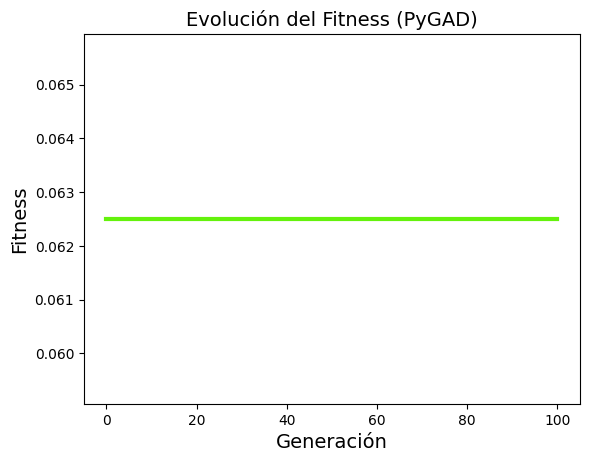

  Día  6: 10 operarios activos -> [OK]


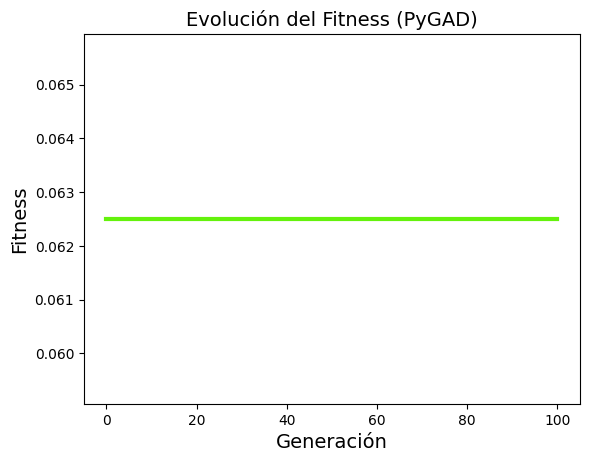

  Día  7: 10 operarios activos -> [OK]


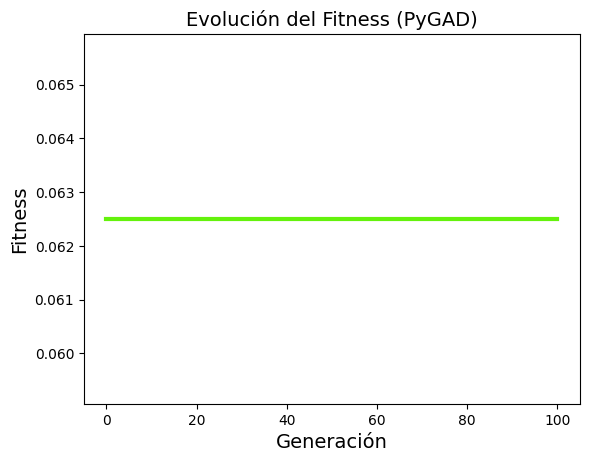

  Día  8:  9 operarios activos -> [OK]


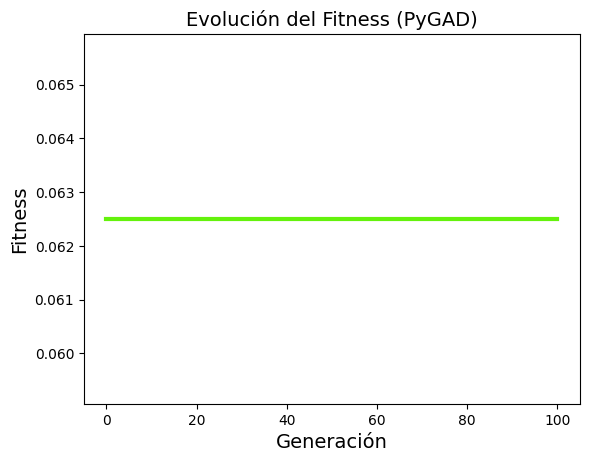

  Día  9: 10 operarios activos -> [OK]


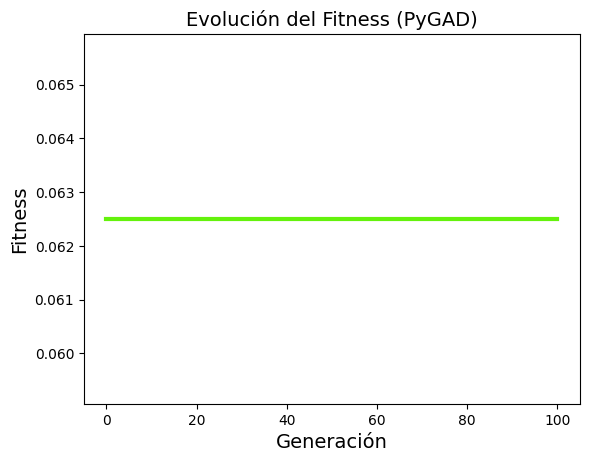

  Día 10: 10 operarios activos -> [OK]


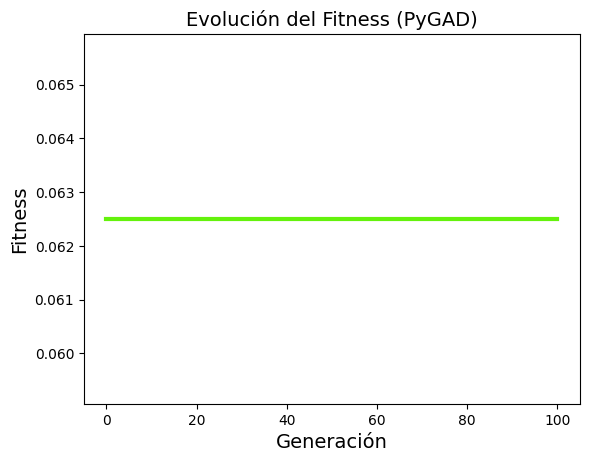

  Día 11: 10 operarios activos -> [OK]


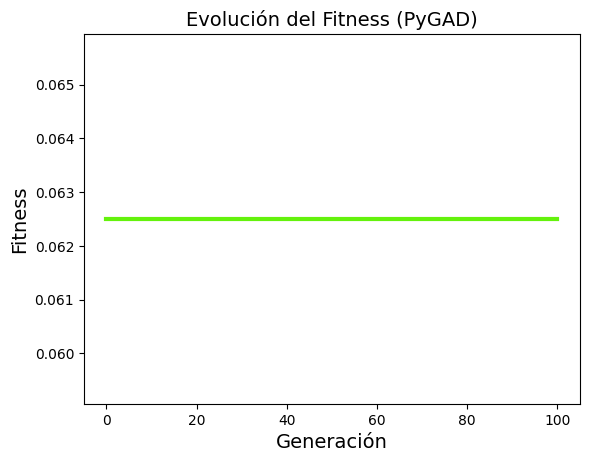

  Día 12: 10 operarios activos -> [OK]


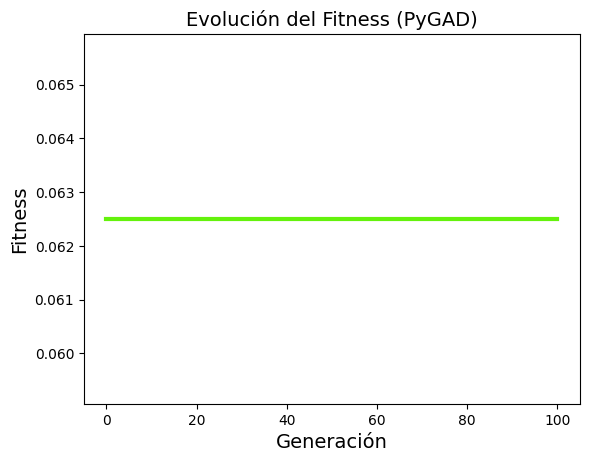

  Día 13: 10 operarios activos -> [OK]


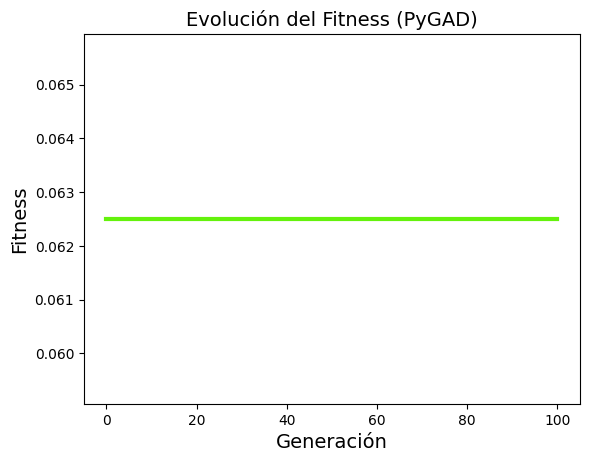

  Día 14: 10 operarios activos -> [OK]


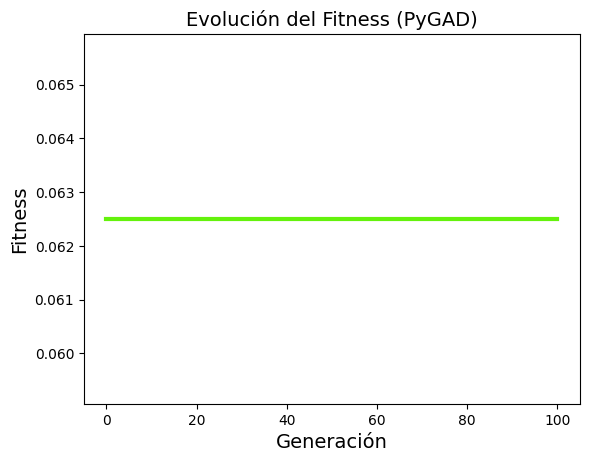

  Día 15:  8 operarios activos -> [OK]


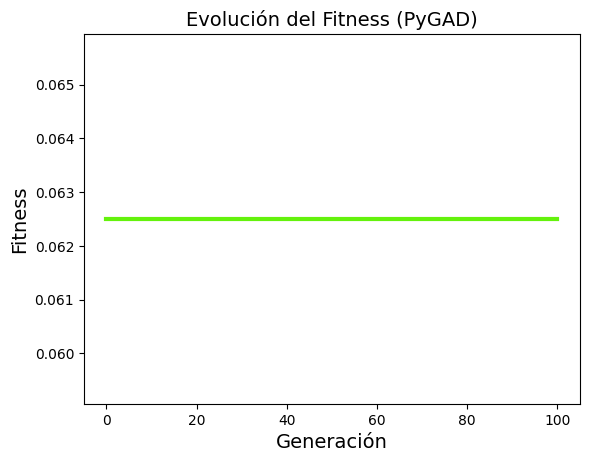

In [ ]:
import numpy as np
import pygad
import matplotlib.pyplot as plt

# =====================================================================
# 1. MODELADO DE DATOS
# =====================================================================
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

NOMBRES_TAREAS = {
    0: "Cimientos", 1: "Muros", 2: "Techo", 3: "Instalaciones", 4: "Revoque",
    5: "Pisos", 6: "Pintura", 7: "Aberturas", 8: "Electricidad", 9: "Final de obra"
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

# =====================================================================
# 2. SIMULADOR Y FUNCIÓN DE APTITUD (FITNESS)
# =====================================================================
def simular_cronograma(cromosoma):
    """
    Simula la ejecución de tareas basándose en el orden del cromosoma.
    Devuelve los días totales y el perfil de operarios por día.
    """
    dias_inicio = {}
    dias_fin = {}
    # Convertimos los genes flotantes de PyGAD a enteros válidos de tareas
    tareas_pendientes = [int(gene) for gene in cromosoma]

    dia_actual = 0
    operarios_por_dia = {}

    while tareas_pendientes:
        for tarea in list(tareas_pendientes):
            duracion, operarios = TASAS_OBRA[tarea]

            # Comprobar si hay sobrecarga de operarios en los días estimados
            conflicto_recursos = False
            for d in range(dia_actual, dia_actual + duracion):
                if operarios_por_dia.get(d, 0) + operarios > MAX_OPERARIOS:
                    conflicto_recursos = True
                    break

            # Asignar días si hay espacio libre
            if not conflicto_recursos:
                dias_inicio[tarea] = dia_actual
                dias_fin[tarea] = dia_actual + duracion

                for d in range(dia_actual, dia_actual + duracion):
                    operarios_por_dia[d] = operarios_por_dia.get(d, 0) + operarios

                tareas_pendientes.remove(tarea)

        dia_actual += 1
        if dia_actual > 150:
            return 150, operarios_por_dia

    dias_totales = max(dias_fin.values()) if dias_fin else 150
    return dias_totales, operarios_por_dia

def fitness_func(ga_instance, solution, solution_idx):
    """
    Función requerida por PyGAD. Debe retornar un valor numérico más alto
    mientras mejor sea la solución.
    """
    dias_totales, operarios_por_dia = simular_cronograma(solution)

    # Penalización dura de seguridad por si se supera el límite de operarios
    if any(v > MAX_OPERARIOS for v in operarios_por_dia.values()):
        fitness = 1.0 / (dias_totales * 100)
    else:
        # Buscamos minimizar los días de obra
        fitness = 1.0 / dias_totales

    return fitness

# =====================================================================
# 3. CONFIGURACIÓN Y EJECUCIÓN DE PYGAD
# =====================================================================

# Parámetros del algoritmo
num_generations = 100
num_parents_mating = 4

sol_per_pop = 50
num_genes = NUM_TAREAS

# Restricciones de los genes para forzar permutaciones sin repeticiones
gene_space = list(TASAS_OBRA.keys())

ga_instance = pygad.GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    fitness_func=fitness_func,
    sol_per_pop=sol_per_pop,
    num_genes=num_genes,
    gene_space=gene_space,
    gene_type=int,
    allow_duplicate_genes=False,         # Crucial para problemas de genes duplicados.
    mutation_type="swap",                # Intercambia tareas para mantener los índices únicos
    mutation_percent_genes=20,           # Porcentaje de genes expuestos a mutación
    crossover_type="single_point",       # PyGAD resolverá la validez debido a allow_duplicate_genes=False
    parent_selection_type="tournament",  # Selección por torneo
    K_tournament=3
)

print("Iniciando la optimización con PyGAD...")
ga_instance.run()
print("¡Optimización finalizada con éxito!\n")

# =====================================================================
# 4. ANÁLISIS DE RESULTADOS
# =====================================================================
solution, solution_fitness, solution_idx = ga_instance.best_solution()

# Convertir la mejor solución encontrada a una lista de enteros limpios
mejor_cronograma = [int(gene) for gene in solution]
dias_totales, operarios_diarios = simular_cronograma(mejor_cronograma)

print("="*60)
print("¡CRONOGRAMA OPTIMIZADO POR PYGAD!")
print("="*60)
print(f"Prioridad óptima (IDs): {mejor_cronograma}")
print(f"Orden recomendado: {', '.join([NOMBRES_TAREAS[i] for i in mejor_cronograma])}")
print(f"Duración total óptima de la obra: {dias_totales} días")
print(f"Valor de Fitness alcanzado: {solution_fitness:.6f}")

print("\nUso diario de operarios (Restricción técnica: Máximo 10):")
for dia in sorted(operarios_diarios.keys()):
    status = "OK" if operarios_diarios[dia] <= MAX_OPERARIOS else "¡EXCEDIDO!"
    print(f"  Día {dia:2d}: {operarios_diarios[dia]:2d} operarios activos -> [{status}]")

# Dibujar la gráfica nativa de PyGAD para el historial de fitness
    ga_instance.plot_fitness(title="Evolución del Fitness (PyGAD)", xlabel="Generación", ylabel="Fitness")
